In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_1samp



In [2]:
# =============================================================================
# 1. CONFIGURACIÓN Y DEFINICIONES
# =============================================================================

# --- PARÁMETROS DEL ANÁLISIS ---
FILE_NAME = 'df_1000_corrected.csv'      # Nombre del archivo
NDC_MEDIAN = 4.66                     # Punto de corte para NDC
COLUMNA_EXPECTATIVA = 'expectativa_sin' # Columna variable independiente
VALOR_EXPECTATIVA = 1                 # Valor específico a filtrar para el análisis detallado

# --- PARÁMETROS VISUALES ---
ORDEN_TRATOS = ['CON','SIN',  'DIST'] # Orden en los ejes X
PALETA_NDC = "muted"                  # Colores para split NDC
PALETA_GEN = "Set2"                # Colores para análisis general
PALETA_DELTAS = "RdBu"                # Colores para diferencias (+/-)

# --- FUNCIONES AUXILIARES ---
def classify_ndc(score):
    """Clasifica el puntaje NDC en High o Low según la mediana global."""
    if pd.isna(score): return 'Unknown'
    return 'High NDC' if score > NDC_MEDIAN else 'Low NDC'


In [3]:

# =============================================================================
# 2. CARGA Y PROCESAMIENTO DE DATOS
# =============================================================================
print(">>> Iniciando Procesamiento de Datos...")

# 2.1 Carga Inicial
try:
    df = pd.read_csv(FILE_NAME)
    print(f"   Archivo '{FILE_NAME}' cargado. Registros totales: {len(df)}")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{FILE_NAME}'.")
    # Detener ejecución o generar datos dummy si es prueba

# 2.2 Preprocesamiento General (Sujetos Únicos y Variables)
# ---------------------------------------------------------
# Crear DF de sujetos únicos
df_u = df.drop_duplicates(subset=['ID_Sujeto']).copy()

# Limpieza y Conversión
df_u['NDC_Score'] = pd.to_numeric(df_u['NDC_Score'], errors='coerce')

# Crear Grupos (NDC y Tratamiento)
df_u['NDC_Group'] = df_u['NDC_Score'].apply(classify_ndc)

# Mapear NDC al DF principal (para tenerlo en todas las filas)
ndc_map = df_u.set_index('ID_Sujeto')['NDC_Group'].to_dict()
df['NDC_Group'] = df['ID_Sujeto'].map(ndc_map).fillna('Unknown')

# Extraer Tratamiento limpio desde 'Dilema'
df['Tratamiento'] = df['Dilema'].str.upper().str.extract(r'(CON|SIN|DIST)', expand=False)



>>> Iniciando Procesamiento de Datos...
   Archivo 'df_1000_corrected.csv' cargado. Registros totales: 354


In [4]:

# 2.3 Creación de DataFrames Derivados (Paneles y Deltas)
# -------------------------------------------------------

# A. Datos Filtrados por Expectativa (Tu foco de análisis principal)
#    Filtrar sujetos que cumplen la condición de expectativa
ids_cumplen_condicion = df_u[df_u[COLUMNA_EXPECTATIVA] == VALOR_EXPECTATIVA]['ID_Sujeto']
df_filtered = df[df['ID_Sujeto'].isin(ids_cumplen_condicion)].copy()
df_u_filtered = df_u[df_u['ID_Sujeto'].isin(ids_cumplen_condicion)].copy()

print(f"   Sujetos filtrados por {COLUMNA_EXPECTATIVA}={VALOR_EXPECTATIVA}: {len(df_u_filtered)}")

# B. Panel Intra-Sujetos (Promedios por Tratamiento y Sujeto)
#    Agrupamos el DF filtrado para tener 1 fila por (Sujeto x Tratamiento)
df_panel_intra = df_filtered.groupby(['ID_Sujeto', 'Tratamiento', 'NDC_Group'])['Mantiene'].mean().reset_index()

# C. Panel Entre-Sujetos (Solo Primer Bloque)
#    Tomamos solo donde Orden_1 == 1
df_panel_inter = df_filtered[df_filtered['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento', 'NDC_Group'])['Mantiene'].mean().reset_index()

# D. Cálculo de Deltas (Diferencias Intra-Sujeto)
#    Pivoteamos para tener tratamientos en columnas: ID | CON | SIN | DIST
df_pivot = df_panel_intra.pivot_table(index=['ID_Sujeto', 'NDC_Group'], 
                                      columns='Tratamiento', 
                                      values='Mantiene').reset_index()

#    Calculamos diferencias
df_pivot['Dif_CON_SIN'] = df_pivot['CON'] - df_pivot['SIN']
df_pivot['Dif_SIN_DIST'] = df_pivot['SIN'] - df_pivot['DIST']

#    "Derretimos" (Melt) para poder graficar fácil con Seaborn
df_deltas = df_pivot.melt(id_vars=['ID_Sujeto', 'NDC_Group'],
                          value_vars=['Dif_CON_SIN', 'Dif_SIN_DIST'],
                          var_name='Comparacion', value_name='Diferencia')

# E. Promedios Generales por Sujeto (Para análisis de Expectativa vs Mantiene)
#    Promedio total de 'Mantiene' por sujeto (indep. del tratamiento) usando TODA la base (no solo el filtro)
df_subj_mean_total = df.groupby(['ID_Sujeto', COLUMNA_EXPECTATIVA])['Mantiene'].mean().reset_index()

print(">>> Procesamiento completado. DataFrames listos para visualización.\n")

   Sujetos filtrados por expectativa_sin=1: 42
>>> Procesamiento completado. DataFrames listos para visualización.




BLOQUE 1: DISTRIBUCIÓN DE EXPECTATIVA


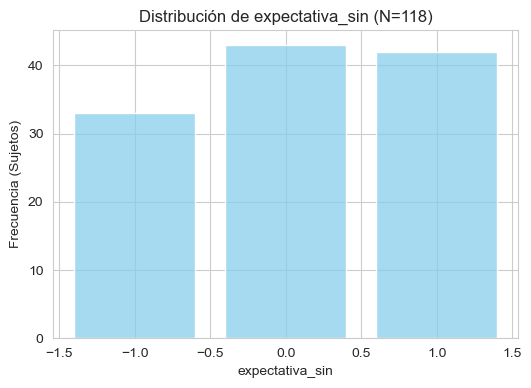


> Conteo de expectativa_sin:
-1    33
 0    43
 1    42
Name: expectativa_sin, dtype: int64

BLOQUE 2: EFECTO TRATAMIENTO (Filtrado: expectativa_sin=1)


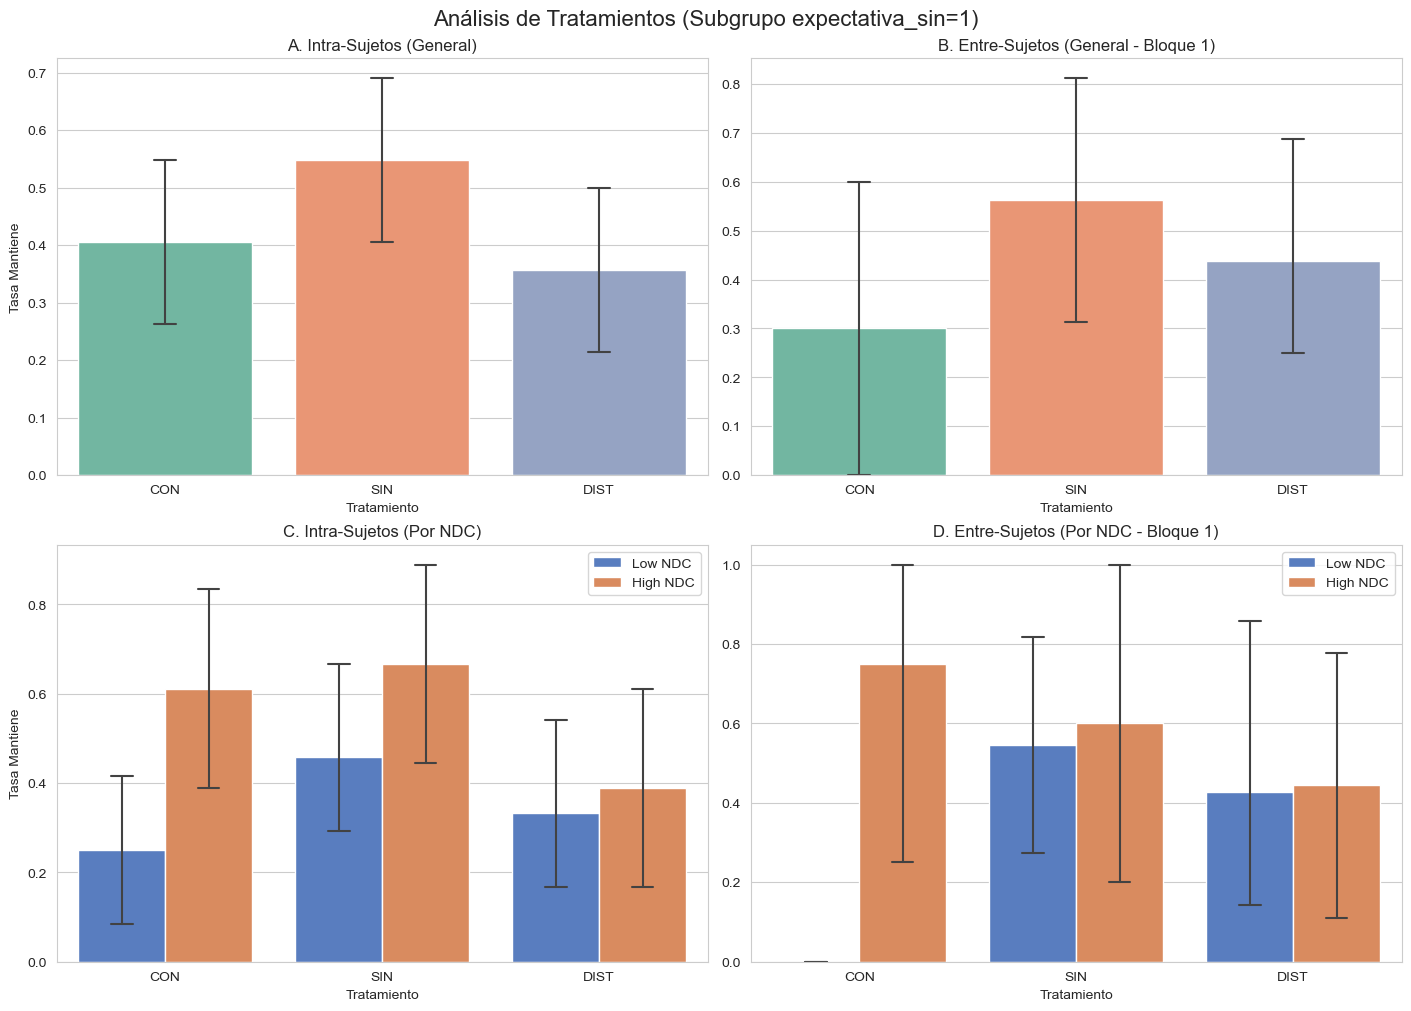


>>> 1. Estadísticas INTRA-Sujetos (General)
             count   mean    sem
Tratamiento                     
CON             42  0.405  0.077
SIN             42  0.548  0.078
DIST            42  0.357  0.075

>>> 2. Estadísticas ENTRE-Sujetos (General - Primer Bloque)
             count   mean    sem
Tratamiento                     
CON             10  0.300  0.153
SIN             16  0.562  0.128
DIST            16  0.438  0.128

>>> 3. Estadísticas INTRA-Sujetos (Por NDC)
                        mean    sem
Tratamiento NDC_Group              
CON         High NDC   0.611  0.118
            Low NDC    0.250  0.090
SIN         High NDC   0.667  0.114
            Low NDC    0.458  0.104
DIST        High NDC   0.389  0.118
            Low NDC    0.333  0.098

>>> 4. Estadísticas ENTRE-Sujetos (Por NDC - Primer Bloque)
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       4  0.750  0.250
            Low NDC        6  0.000  0.00

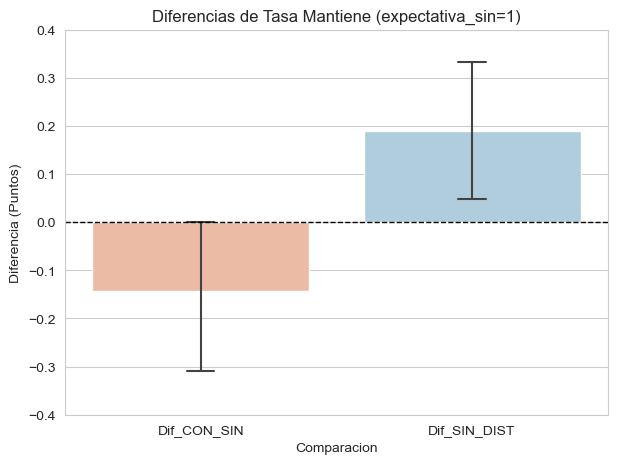


>>> Estadísticas: Deltas
              count    mean     sem  p-value
Comparacion                                 
Dif_CON_SIN      42 -0.1429  0.0804   0.0832
Dif_SIN_DIST     42  0.1905  0.0780   0.0190

BLOQUE 4: MANTIENE SEGÚN NIVEL DE EXPECTATIVA (Toda la muestra)


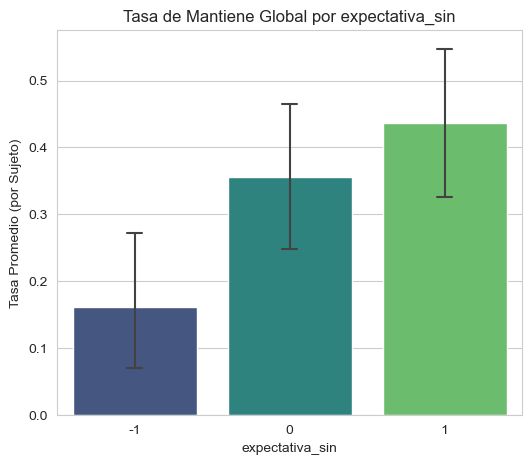


>>> Estadísticas por expectativa_sin:
                 count   mean    sem
expectativa_sin                     
-1                  33  0.162  0.051
 0                  43  0.357  0.059
 1                  42  0.437  0.061


In [5]:


# =============================================================================
# 3. VISUALIZACIONES Y TABLAS
# =============================================================================
sns.set_style("whitegrid") # Estilo general

# --- BLOQUE 1: DESCRIPCIÓN DE LA MUESTRA ---
print(f"\n{'='*60}\nBLOQUE 1: DISTRIBUCIÓN DE EXPECTATIVA\n{'='*60}")
plt.figure(figsize=(6, 4))
if COLUMNA_EXPECTATIVA in df_u.columns:
    sns.histplot(df_u[COLUMNA_EXPECTATIVA], discrete=True, kde=False, color='skyblue', shrink=0.8)
    plt.title(f'Distribución de {COLUMNA_EXPECTATIVA} (N={len(df_u)})')
    plt.ylabel('Frecuencia (Sujetos)')
    plt.show()
    
    # Tabla
    print(f"\n> Conteo de {COLUMNA_EXPECTATIVA}:")
    print(df_u[COLUMNA_EXPECTATIVA].value_counts().sort_index())
else:
    print(f"Advertencia: Columna {COLUMNA_EXPECTATIVA} no encontrada.")

# --- BLOQUE 2: EFECTO TRATAMIENTO (GENERAL Y NDC) ---
# Usamos el subset filtrado por expectativa
print(f"\n{'='*60}\nBLOQUE 2: EFECTO TRATAMIENTO (Filtrado: {COLUMNA_EXPECTATIVA}={VALOR_EXPECTATIVA})\n{'='*60}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# 2.1 Intra - General
sns.barplot(data=df_panel_intra, x='Tratamiento', y='Mantiene', order=ORDEN_TRATOS, 
            capsize=0.1, errwidth=1.5, palette=PALETA_GEN, ax=axes[0,0])
axes[0,0].set_title('A. Intra-Sujetos (General)')
axes[0,0].set_ylabel('Tasa Mantiene')

# 2.2 Entre - General
sns.barplot(data=df_panel_inter, x='Tratamiento', y='Mantiene', order=ORDEN_TRATOS, 
            capsize=0.1, errwidth=1.5, palette=PALETA_GEN, ax=axes[0,1])
axes[0,1].set_title('B. Entre-Sujetos (General - Bloque 1)')
axes[0,1].set_ylabel('')

# 2.3 Intra - Por NDC
sns.barplot(data=df_panel_intra, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=ORDEN_TRATOS, 
            capsize=0.1, errwidth=1.5, palette=PALETA_NDC, ax=axes[1,0])
axes[1,0].set_title('C. Intra-Sujetos (Por NDC)')
axes[1,0].set_ylabel('Tasa Mantiene')
axes[1,0].legend(loc='upper right', frameon=True)

# 2.4 Entre - Por NDC
sns.barplot(data=df_panel_inter, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=ORDEN_TRATOS, 
            capsize=0.1, errwidth=1.5, palette=PALETA_NDC, ax=axes[1,1])
axes[1,1].set_title('D. Entre-Sujetos (Por NDC - Bloque 1)')
axes[1,1].set_ylabel('')
axes[1,1].legend(loc='upper right', frameon=True)

plt.suptitle(f"Análisis de Tratamientos (Subgrupo {COLUMNA_EXPECTATIVA}={VALOR_EXPECTATIVA})", fontsize=16)
plt.show()

# --- TABLAS RESUMEN BLOQUE 2 ---

print("\n>>> 1. Estadísticas INTRA-Sujetos (General)")
print(df_panel_intra.groupby(['Tratamiento'])['Mantiene']
      .agg(['count', 'mean', 'sem']).reindex(ORDEN_TRATOS).round(3))

print("\n>>> 2. Estadísticas ENTRE-Sujetos (General - Primer Bloque)")
print(df_panel_inter.groupby(['Tratamiento'])['Mantiene']
      .agg(['count', 'mean', 'sem']).reindex(ORDEN_TRATOS).round(3))

print("\n>>> 3. Estadísticas INTRA-Sujetos (Por NDC)")
print(df_panel_intra.groupby(['Tratamiento', 'NDC_Group'])['Mantiene']
      .agg(['mean', 'sem']).reindex(ORDEN_TRATOS, level=0).round(3))

print("\n>>> 4. Estadísticas ENTRE-Sujetos (Por NDC - Primer Bloque)")
print(df_panel_inter.groupby(['Tratamiento', 'NDC_Group'])['Mantiene']
      .agg(['count', 'mean', 'sem']).reindex(ORDEN_TRATOS, level=0).round(3))


# --- BLOQUE 3: ANÁLISIS DE DIFERENCIAS (DELTAS) ---
print(f"\n{'='*60}\nBLOQUE 3: DIFERENCIAS (DELTAS) INTRA-SUJETO\n{'='*60}")

plt.figure(figsize=(7, 5))
sns.barplot(data=df_deltas, x='Comparacion', y='Diferencia', capsize=0.1, errwidth=1.5, palette=PALETA_DELTAS)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Diferencias de Tasa Mantiene ({COLUMNA_EXPECTATIVA}={VALOR_EXPECTATIVA})')
plt.ylim(-0.4, 0.4) # Ajustar según datos
plt.ylabel('Diferencia (Puntos)')
plt.show()

# Tabla Deltas + Test T
print("\n>>> Estadísticas: Deltas")
stats_deltas = df_deltas.groupby('Comparacion')['Diferencia'].agg(['count', 'mean', 'sem'])
# Calcular p-value (H0: media = 0)
p_vals = df_deltas.groupby('Comparacion')['Diferencia'].apply(lambda x: ttest_1samp(x.dropna(), 0)[1])
stats_deltas['p-value'] = p_vals
print(stats_deltas.round(4))


# --- BLOQUE 4: EFECTO DE LA EXPECTATIVA (GENERAL) ---
print(f"\n{'='*60}\nBLOQUE 4: MANTIENE SEGÚN NIVEL DE EXPECTATIVA (Toda la muestra)\n{'='*60}")

plt.figure(figsize=(6, 5))
sns.barplot(data=df_subj_mean_total, x=COLUMNA_EXPECTATIVA, y='Mantiene', capsize=0.1, errwidth=1.5, palette="viridis")
plt.title(f'Tasa de Mantiene Global por {COLUMNA_EXPECTATIVA}')
plt.ylabel('Tasa Promedio (por Sujeto)')
plt.show()

print(f"\n>>> Estadísticas por {COLUMNA_EXPECTATIVA}:")
print(df_subj_mean_total.groupby(COLUMNA_EXPECTATIVA)['Mantiene'].agg(['count', 'mean', 'sem']).round(3))